<a href="https://colab.research.google.com/github/Alfiaadmy/food-security-ews-jatim/blob/main/notebooks/02_EDA_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) Time Series
## Early Warning System Produksi Padi Jawa Timur

Notebook ini bertujuan mengeksplorasi karakteristik data time series produksi padi dan variabel Earth Observation pada 38 kabupaten/kota di Jawa Timur periode Januari 2018–Desember 2026.

Analisis meliputi:

- Statistik deskriptif
- Trend
- Seasonality
- Distribusi data
- Monthly pattern
- Yearly trend
- Hubungan awal antar variabel

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import plotly.express as px
import plotly.graph_objects as go

import missingno as msno

plt.style.use("ggplot")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/0. BISMILLAH TA LULUS 3,5 TAHUN SUMMA CUMLAUDE AMIINN YA ALLAH/DATA/DATA DIPAKAI CLEAN/MASTER_DATASET_EWS_2018_2026.csv"

df = pd.read_csv(path)

df.head()

,Kabupaten,Tahun,Bulan,Produksi_Padi,NDVI_Sawah,Curah_Hujan,Suhu_Udara,Kelembapan_Tanah,Penduduk,Konsumsi_Beras
0,Bangkalan,2018,1,4739.48,0.648887,452.229775,26.670489,0.417533,979.0,1.740
1,Banyuwangi,2018,1,27729.16,0.612058,480.038452,24.209085,0.377716,1610.0,1.640
2,Blitar,2018,1,2123.29,0.690331,446.882096,24.297989,0.379008,1158.0,1.201
3,Bojonegoro,2018,1,26071.89,0.654740,358.860599,25.643728,0.450168,1247.0,1.629
4,Bondowoso,2018,1,8154.93,0.625624,597.027699,22.256094,0.388150,772.0,1.625


#Informasi Dataset

In [4]:
df.shape

(3800, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Kabupaten         3800 non-null   object 
 1   Tahun             3800 non-null   int64  
 2   Bulan             3800 non-null   int64  
 3   Produksi_Padi     3800 non-null   float64
 4   NDVI_Sawah        3800 non-null   float64
 5   Curah_Hujan       3800 non-null   float64
 6   Suhu_Udara        3800 non-null   float64
 7   Kelembapan_Tanah  3800 non-null   float64
 8   Penduduk          3800 non-null   float64
 9   Konsumsi_Beras    3800 non-null   float64
dtypes: float64(7), int64(2), object(1)
memory usage: 297.0+ KB


In [6]:
df.describe()

,Tahun,Bulan,Produksi_Padi,NDVI_Sawah,Curah_Hujan,Suhu_Udara,Kelembapan_Tanah,Penduduk,Konsumsi_Beras
count,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03,3800.000000
mean,2021.680000,6.340000,21971.242784,0.581687,188.720451,25.320472,0.318191,1.775552e+05,1.434329
std,2.412288,3.479596,31377.286908,0.091037,156.029669,1.808080,0.101832,4.891315e+05,0.189609
min,2018.000000,1.000000,0.000000,0.253754,0.000000,18.899651,0.058439,1.280000e+02,1.049000
25%,2020.000000,3.000000,1181.275000,0.530209,39.388467,24.191667,0.230757,7.445000e+02,1.296000
50%,2022.000000,6.000000,11379.140000,0.591838,163.317577,25.282117,0.350671,1.131800e+03,1.440000
75%,2024.000000,9.000000,28954.690000,0.645947,310.800793,26.680359,0.405071,1.754400e+03,1.569000
max,2026.000000,12.000000,283043.450000,0.815607,692.893586,29.929373,0.472548,2.940265e+06,1.980000


In [7]:
df.isna().sum()

,0
Kabupaten,0
Tahun,0
Bulan,0
Produksi_Padi,0
NDVI_Sawah,0
Curah_Hujan,0
Suhu_Udara,0
Kelembapan_Tanah,0
Penduduk,0
Konsumsi_Beras,0


In [8]:
df.duplicated().sum()

np.int64(0)

#Kolom Datetime

In [9]:
df["Tanggal"] = pd.to_datetime(
    dict(
        year=df["Tahun"],
        month=df["Bulan"],
        day=1
    )
)

df = df.sort_values(["Kabupaten","Tanggal"])

df.head()

,Kabupaten,Tahun,Bulan,Produksi_Padi,NDVI_Sawah,Curah_Hujan,Suhu_Udara,Kelembapan_Tanah,Penduduk,Konsumsi_Beras,Tanggal
0,Bangkalan,2018,1,4739.48,0.648887,452.229775,26.670489,0.417533,979.0,1.74,2018-01-01
38,Bangkalan,2018,2,46564.49,0.648455,200.052771,26.291750,0.417739,979.0,1.74,2018-02-01
76,Bangkalan,2018,3,68927.85,0.601144,228.929244,26.834799,0.413996,979.0,1.74,2018-03-01
114,Bangkalan,2018,4,27021.81,0.613507,100.549449,27.720254,0.383438,979.0,1.74,2018-04-01
152,Bangkalan,2018,5,12847.50,0.651467,30.814636,28.081764,0.257387,979.0,1.74,2018-05-01


#Statistik Deskriptif

In [10]:
numeric_cols = [
    "Produksi_Padi",
    "NDVI_Sawah",
    "Curah_Hujan",
    "Suhu_Udara",
    "Kelembapan_Tanah",
    "Penduduk",
    "Konsumsi_Beras"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Produksi_Padi,3800.0,21971.242784,31377.286908,0.000000,1181.275000,11379.140000,28954.690000,2.830435e+05
NDVI_Sawah,3800.0,0.581687,0.091037,0.253754,0.530209,0.591838,0.645947,8.156069e-01
Curah_Hujan,3800.0,188.720451,156.029669,0.000000,39.388467,163.317577,310.800793,6.928936e+02
Suhu_Udara,3800.0,25.320472,1.808080,18.899651,24.191667,25.282117,26.680359,2.992937e+01
Kelembapan_Tanah,3800.0,0.318191,0.101832,0.058439,0.230757,0.350671,0.405071,4.725484e-01
Penduduk,3800.0,177555.171263,489131.523247,128.000000,744.500000,1131.800000,1754.400000,2.940265e+06
Konsumsi_Beras,3800.0,1.434329,0.189609,1.049000,1.296000,1.440000,1.569000,1.980000e+00


#Agregasi Bulanan Provinsi

In [11]:
provinsi = (
    df.groupby("Tanggal")
    .agg({
        "Produksi_Padi":"sum",
        "NDVI_Sawah":"mean",
        "Curah_Hujan":"mean",
        "Suhu_Udara":"mean",
        "Kelembapan_Tanah":"mean"
    })
    .reset_index()
)

provinsi.head()

,Tanggal,Produksi_Padi,NDVI_Sawah,Curah_Hujan,Suhu_Udara,Kelembapan_Tanah
0,2018-01-01,211336.91,0.595445,448.781862,24.732052,0.413247
1,2018-02-01,960555.39,0.660311,294.293183,24.549229,0.411149
2,2018-03-01,2293296.40,0.625823,238.948977,24.989717,0.403024
3,2018-04-01,1345462.55,0.616438,108.113025,25.575336,0.375432
4,2018-05-01,635297.04,0.625557,40.688957,25.671961,0.259526


#Trend Produksi Padi

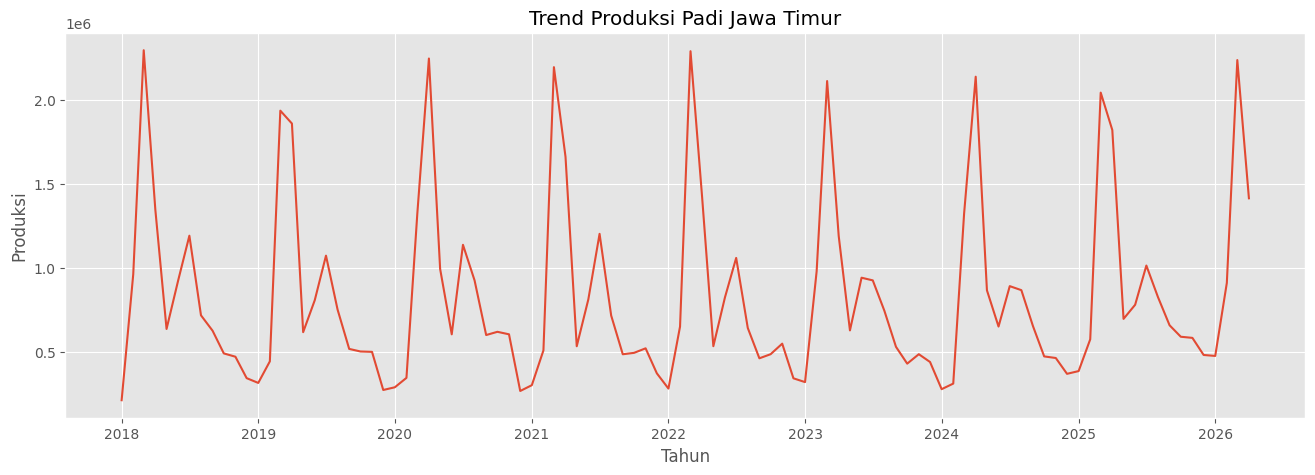

In [12]:
plt.figure(figsize=(16,5))

plt.plot(
    provinsi["Tanggal"],
    provinsi["Produksi_Padi"]
)

plt.title("Trend Produksi Padi Jawa Timur")

plt.xlabel("Tahun")

plt.ylabel("Produksi")

plt.show()

#Trend EO

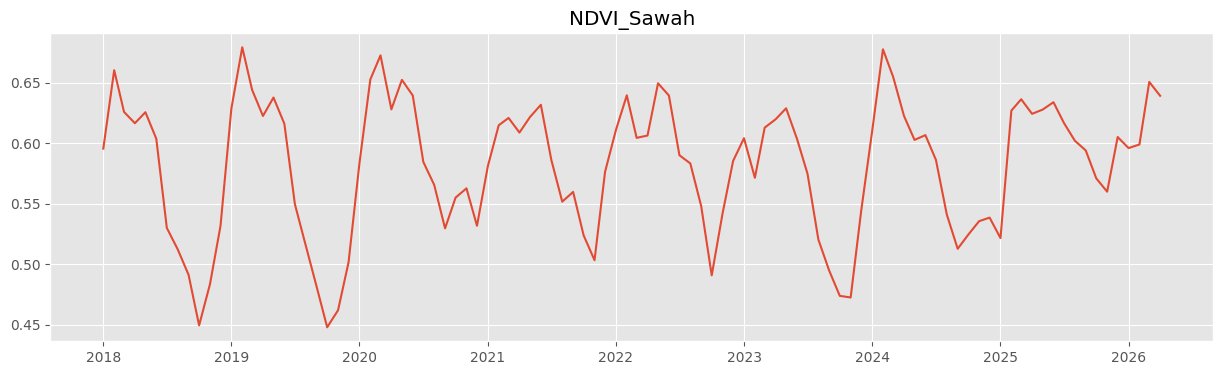

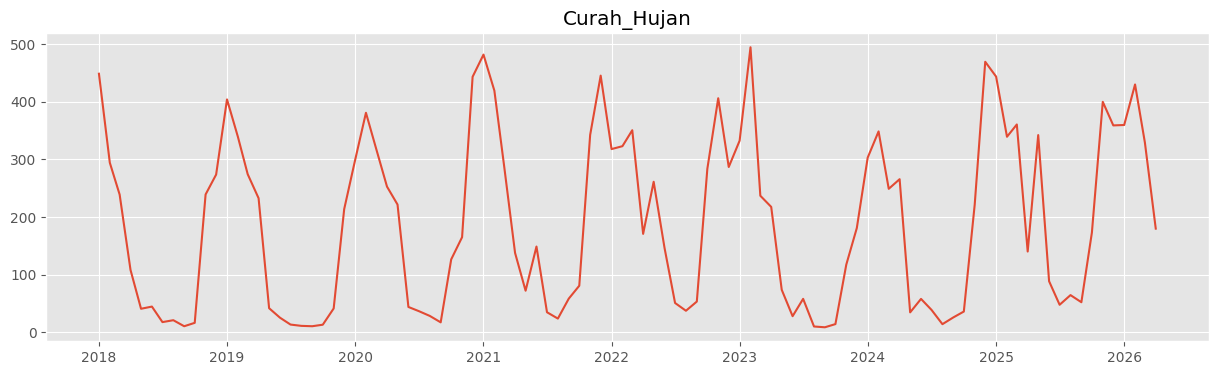

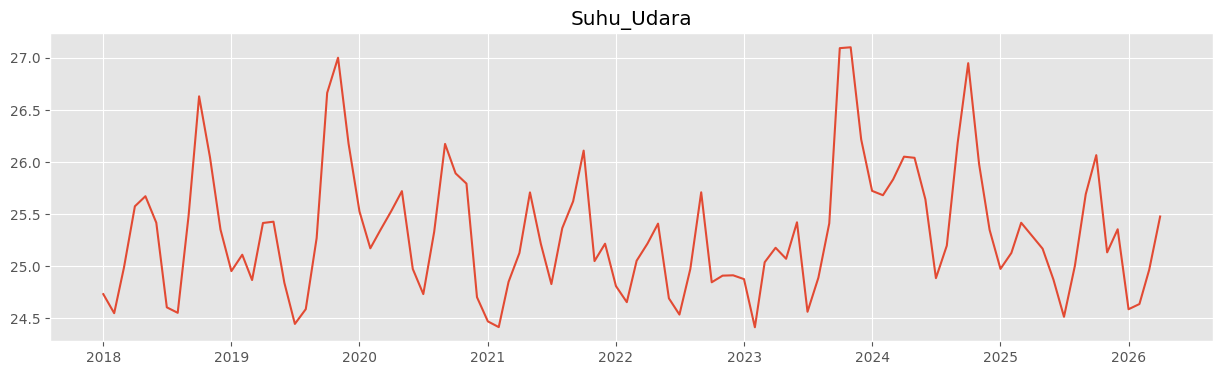

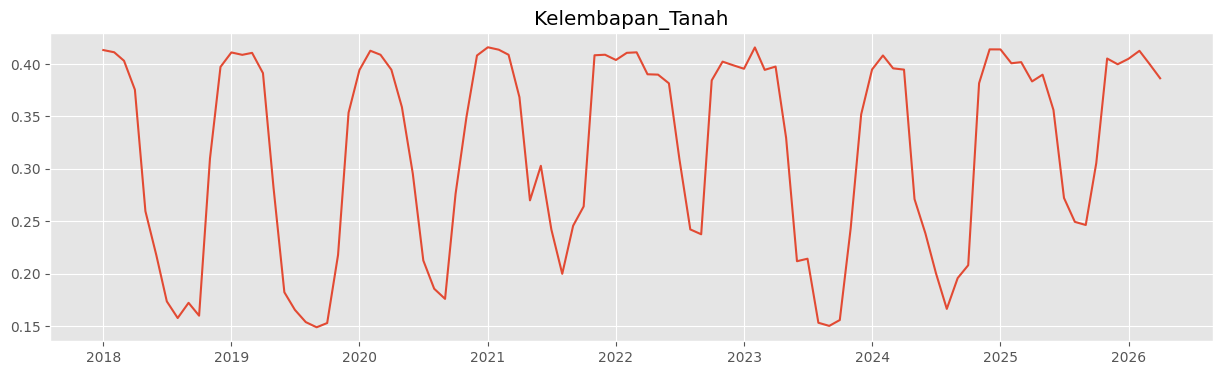

In [13]:
variables = [
    "NDVI_Sawah",
    "Curah_Hujan",
    "Suhu_Udara",
    "Kelembapan_Tanah"
]

for col in variables:

    plt.figure(figsize=(15,4))

    plt.plot(
        provinsi["Tanggal"],
        provinsi[col]
    )

    plt.title(col)

    plt.show()

#Monthly Boxplot

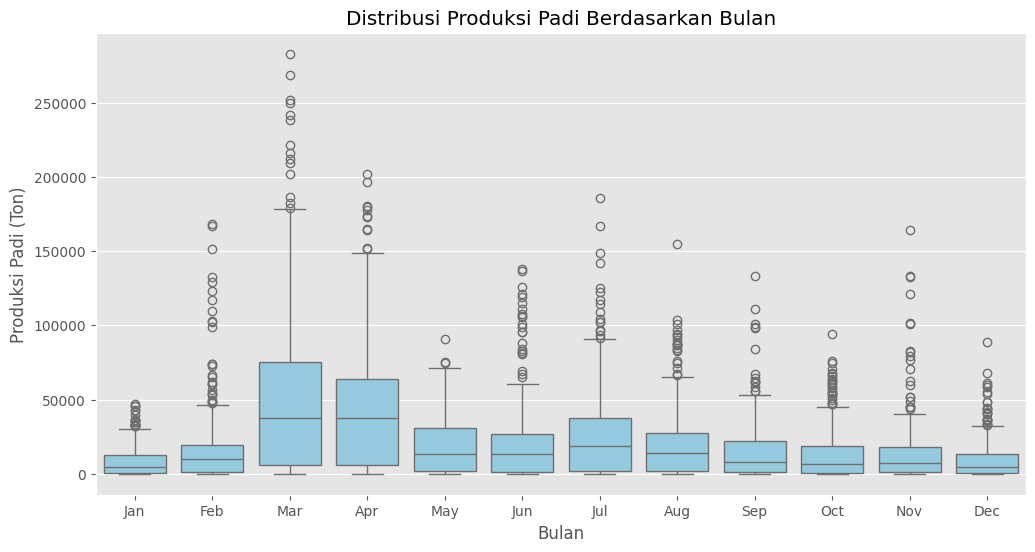

In [20]:
import calendar
import seaborn as sns
import matplotlib.pyplot as plt

# Mapping nama bulan
bulan_order = list(calendar.month_abbr)[1:]   # Jan, Feb, ..., Dec

df["Nama_Bulan"] = df["Bulan"].apply(lambda x: calendar.month_abbr[x])

# Jadikan kategori berurutan
df["Nama_Bulan"] = pd.Categorical(
    df["Nama_Bulan"],
    categories=bulan_order,
    ordered=True
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Nama_Bulan",
    y="Produksi_Padi",
    color="skyblue"
)

plt.title("Distribusi Produksi Padi Berdasarkan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Produksi Padi (Ton)")

plt.show()

#Yearly Trend

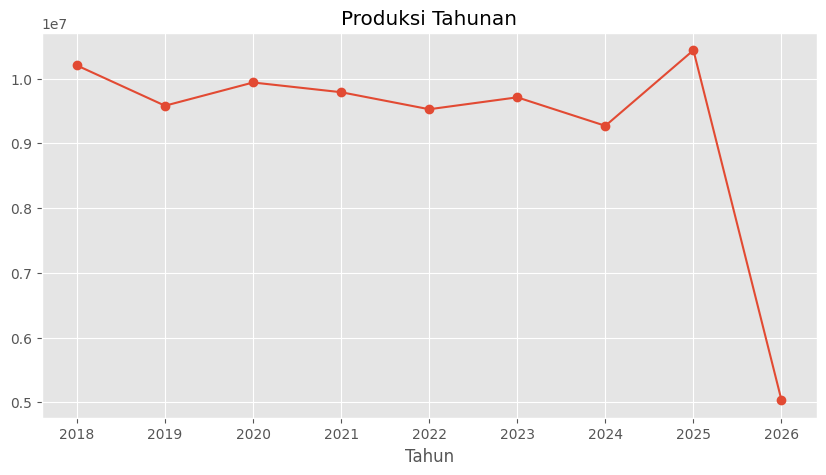

In [15]:
yearly = (
    df.groupby("Tahun")["Produksi_Padi"]
    .sum()
)

yearly.plot(
    marker="o",
    figsize=(10,5)
)

plt.title("Produksi Tahunan")

plt.show()

In [19]:
df.groupby("Tahun")["Bulan"].max()

,Bulan
Tahun,
2018,12
2019,12
2020,12
2021,12
2022,12
2023,12
2024,12
2025,12
2026,4


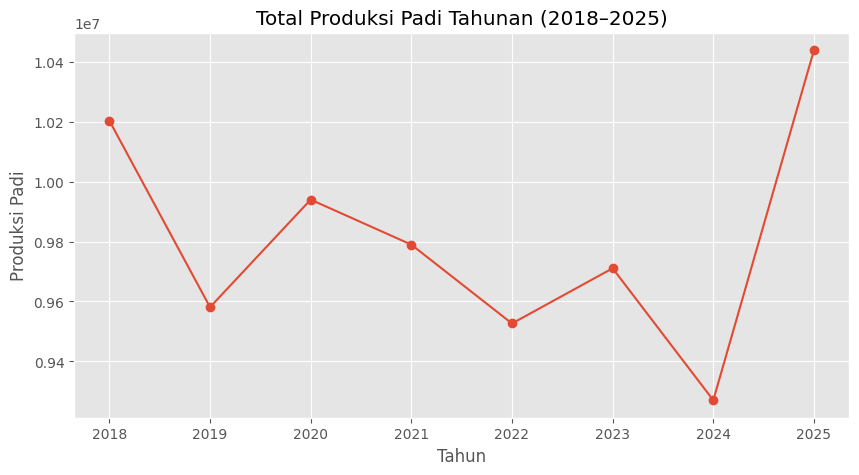

In [31]:
yearly = (
    df[df["Tahun"] != 2026]
    .groupby("Tahun")["Produksi_Padi"]
    .sum()
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly.index,
    yearly.values,
    marker="o"
)

plt.title("Total Produksi Padi Tahunan (2018–2025)")
plt.xlabel("Tahun")
plt.ylabel("Produksi Padi")

plt.show()

#Heatmap Tahun × Bulan

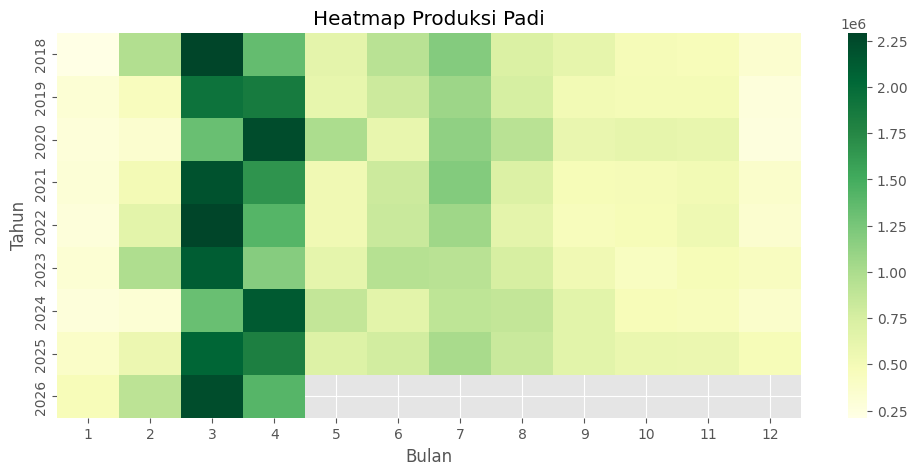

In [16]:
pivot = (
    df.groupby(
        ["Tahun","Bulan"]
    )["Produksi_Padi"]
    .sum()
    .unstack()
)

import seaborn as sns

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    cmap="YlGn"
)

plt.title("Heatmap Produksi Padi")

plt.show()

#Distribusi Variabel EO

In [17]:
for col in variables:

    fig = px.histogram(
        df,
        x=col,
        nbins=40,
        title=col
    )

    fig.show()

#Korelasi Awal

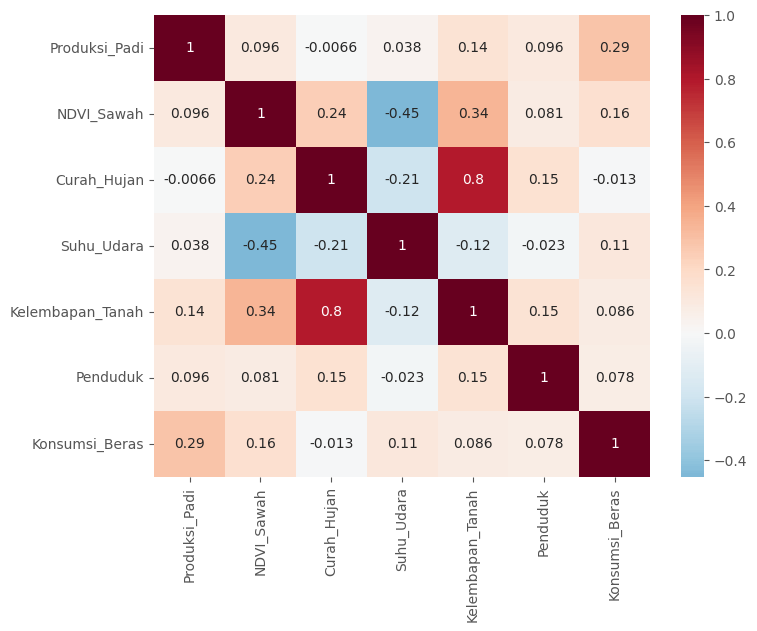

In [18]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.show()

#Top Kabupaten Produksi

In [21]:
# Total produksi per kabupaten
kab_prod = (
    df.groupby("Kabupaten")["Produksi_Padi"]
    .sum()
    .sort_values(ascending=False)
)

display(kab_prod.head(10))
display(kab_prod.tail(10))

,Produksi_Padi
Kabupaten,
Lamongan,7167196.66
Ngawi,6459845.18
Bojonegoro,6308234.87
Jember,5365056.56
Tuban,4484588.97
Banyuwangi,3900063.42
Madiun,3650401.50
Nganjuk,3504437.25
Gresik,3236266.10


,Produksi_Padi
Kabupaten,
Pacitan,822475.32
Kota Madiun,94052.99
Kota Malang,90916.40
Kota Surabaya,77203.48
Kota Pasuruan,75188.36
Kota Probolinggo,69691.02
Kota Kediri,69632.02
Kota Blitar,47145.31
Kota Batu,39872.57


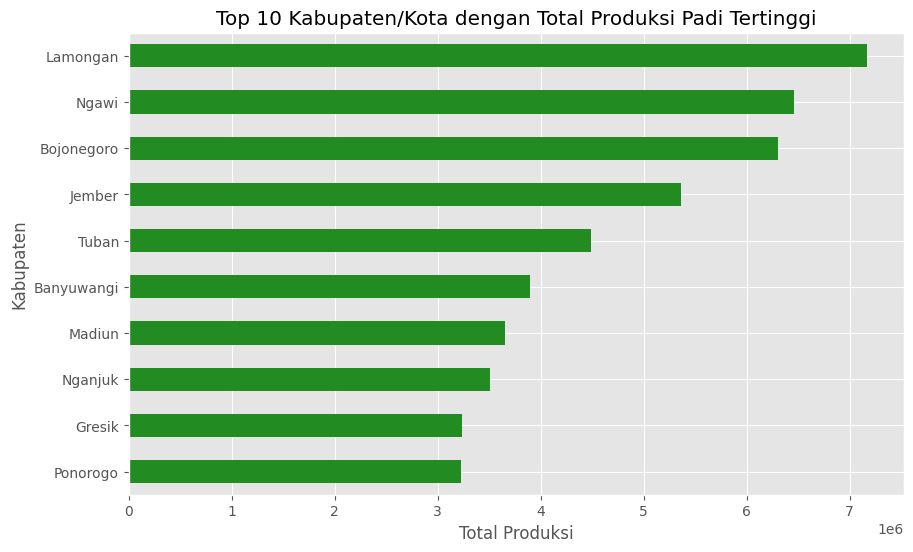

In [32]:
plt.figure(figsize=(10,6))

kab_prod.head(10).sort_values().plot(
    kind="barh",
    color="forestgreen"
)

plt.title("Top 10 Kabupaten/Kota dengan Total Produksi Padi Tertinggi")
plt.xlabel("Total Produksi")

plt.show()

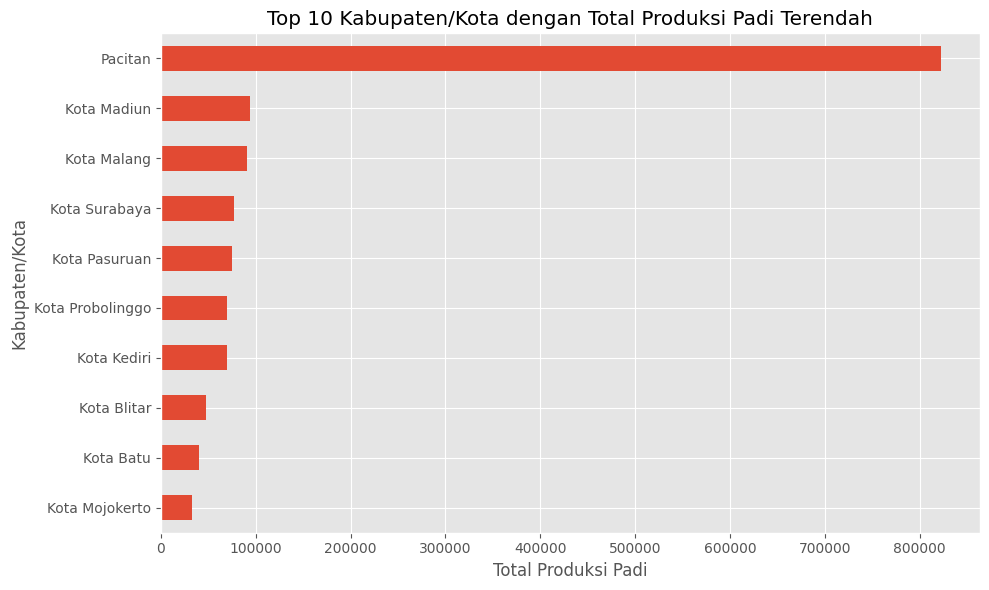

In [23]:
plt.figure(figsize=(10,6))

kab_prod.tail(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Kabupaten/Kota dengan Total Produksi Padi Terendah")
plt.xlabel("Total Produksi Padi")
plt.ylabel("Kabupaten/Kota")

plt.tight_layout()
plt.show()

#Missing Pattern

In [24]:
!pip install missingno

In [25]:
import missingno as msno

<Figure size 1200x500 with 0 Axes>

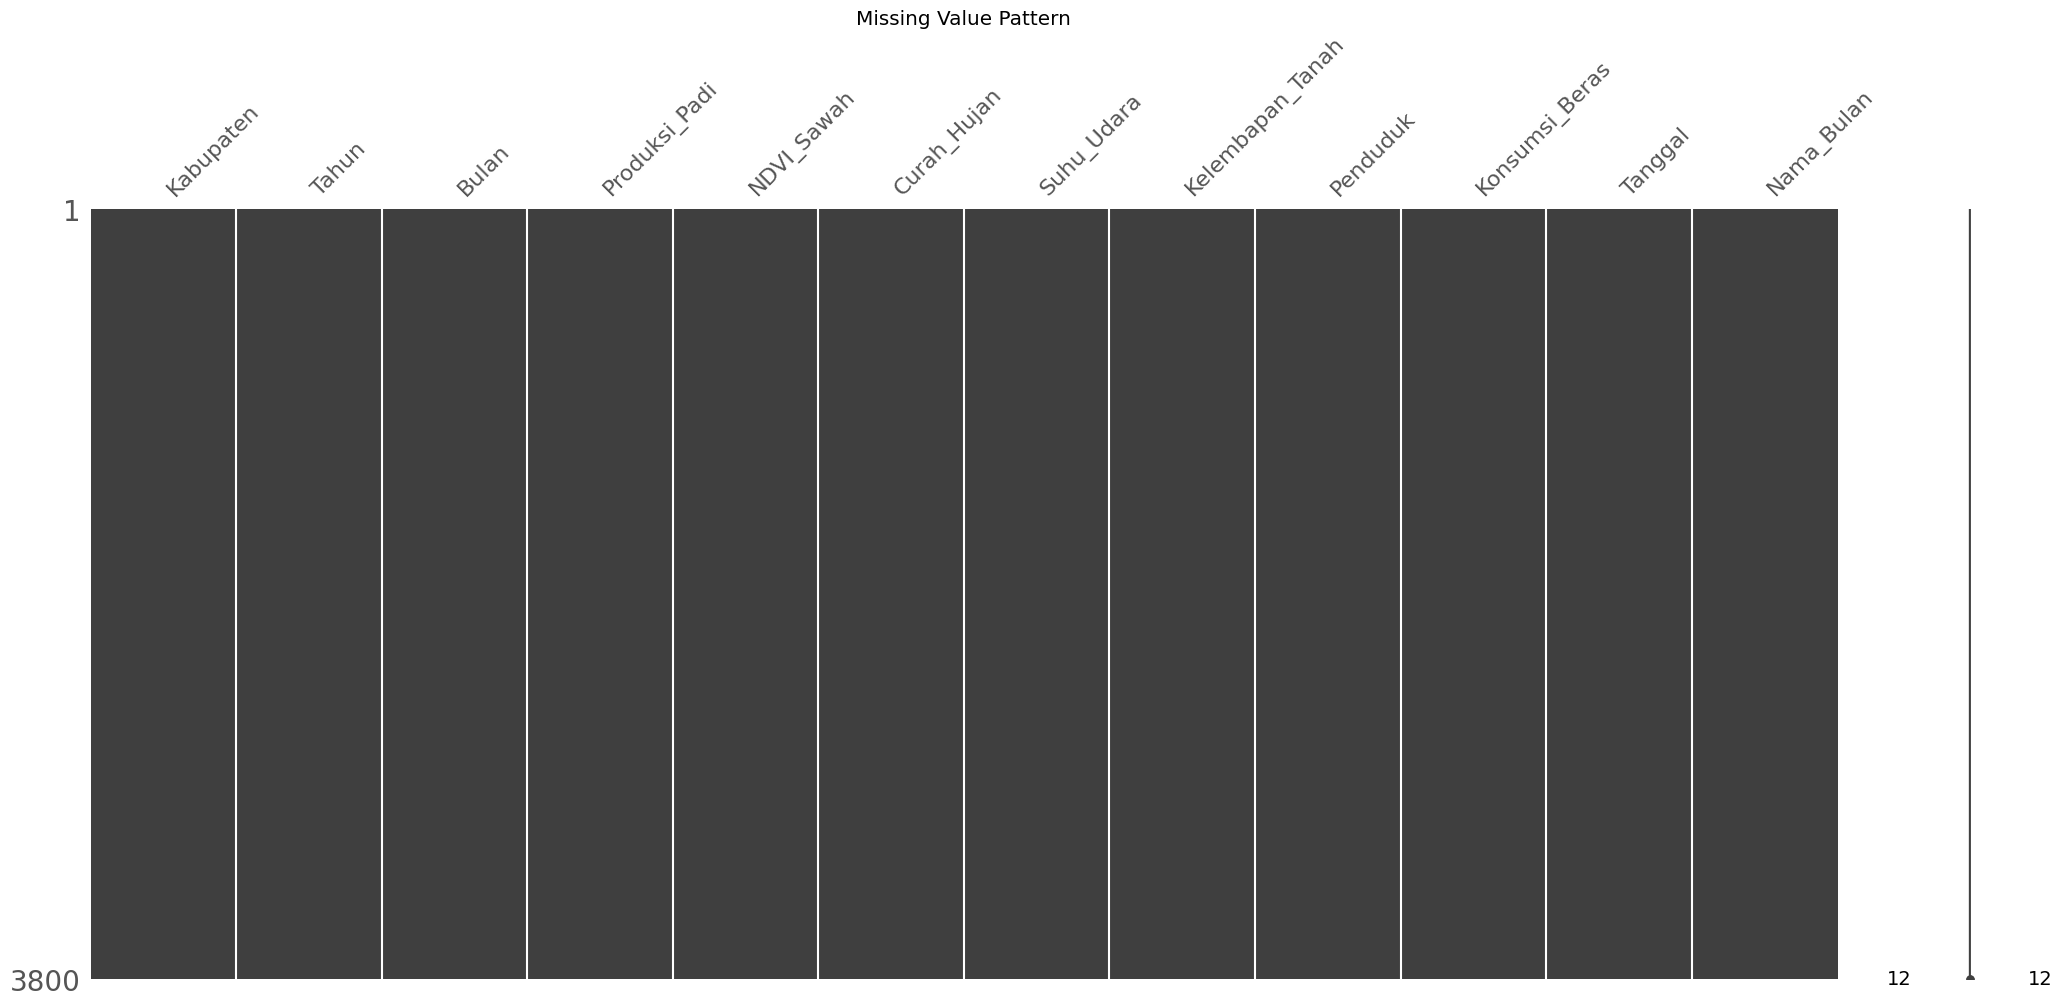

In [26]:
plt.figure(figsize=(12,5))

msno.matrix(df)

plt.title("Missing Value Pattern")

plt.show()

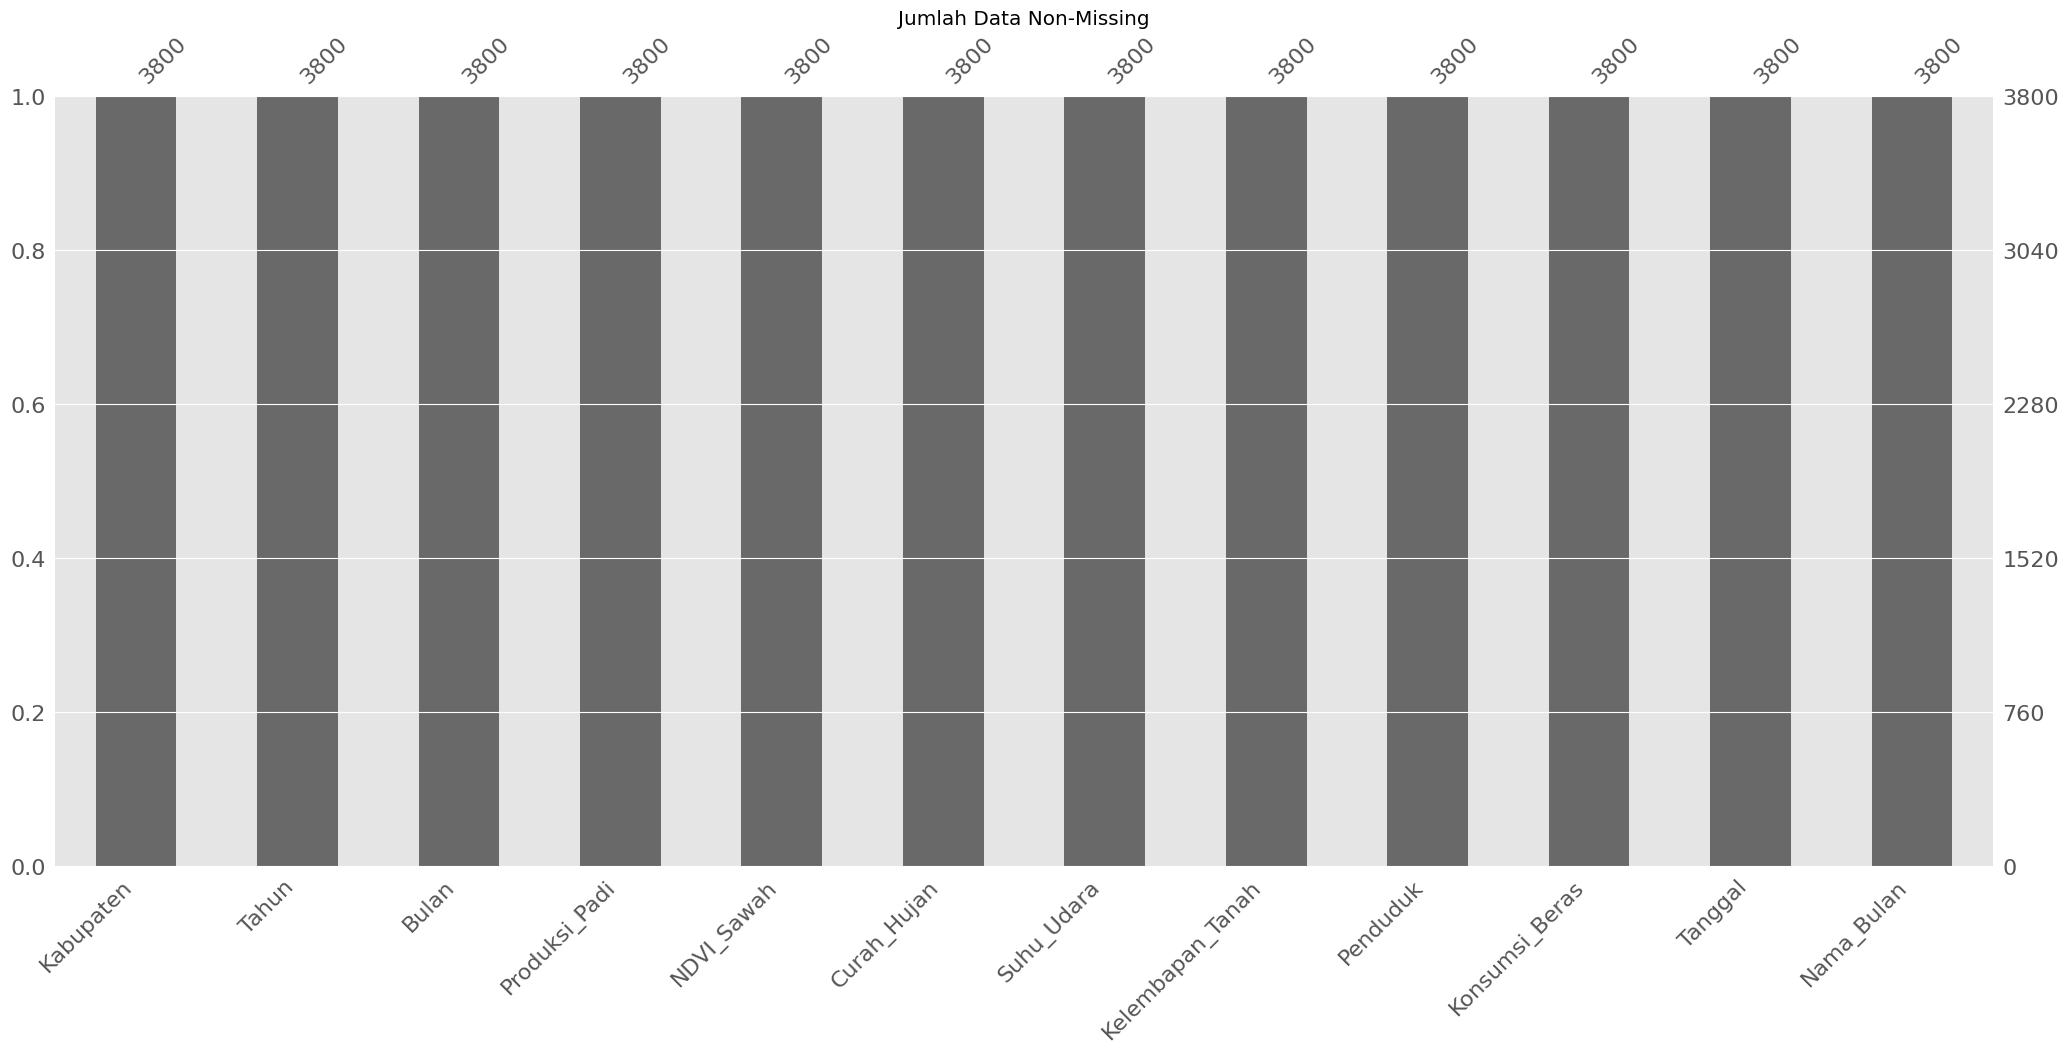

In [27]:
msno.bar(df)

plt.title("Jumlah Data Non-Missing")

plt.show()

In [28]:
numeric_cols = [
    "Produksi_Padi",
    "NDVI_Sawah",
    "Curah_Hujan",
    "Suhu_Udara",
    "Kelembapan_Tanah",
    "Penduduk",
    "Konsumsi_Beras"
]

summary = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Std": df[numeric_cols].std(),
    "Variance": df[numeric_cols].var(),
})

summary["CV (%)"] = (
    summary["Std"] / summary["Mean"]
) * 100

summary = summary.round(3)

summary

,Mean,Std,Variance,CV (%)
Produksi_Padi,21971.243,31377.287,9.845341e+08,142.811
NDVI_Sawah,0.582,0.091,8.000000e-03,15.650
Curah_Hujan,188.720,156.030,2.434526e+04,82.678
Suhu_Udara,25.320,1.808,3.269000e+00,7.141
Kelembapan_Tanah,0.318,0.102,1.000000e-02,32.003
Penduduk,177555.171,489131.523,2.392496e+11,275.481
Konsumsi_Beras,1.434,0.190,3.600000e-02,13.219


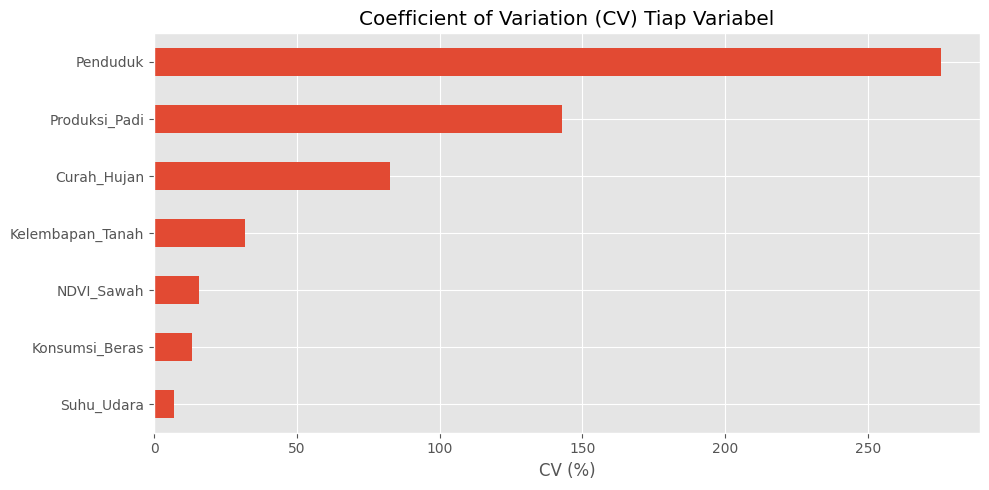

In [30]:
plt.figure(figsize=(10,5))

summary["CV (%)"].sort_values().plot(
    kind="barh"
)

plt.title("Coefficient of Variation (CV) Tiap Variabel")

plt.xlabel("CV (%)")

plt.tight_layout()

plt.show()